In [1]:
#Import libs
import time
import numpy as np
import pandas as pd
import yfinance as yf
import torch
import torch.nn as nn
import torch .optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
#Load data
df = yf.download("SPY", start="2010-01-01", end="2024-01-01", interval="1d")

[*********************100%***********************]  1 of 1 completed


In [3]:
df

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2010-01-04,84.578491,84.623268,83.220220,83.862041,118944600
2010-01-05,84.802406,84.839724,84.220291,84.526278,111579900
2010-01-06,84.862083,85.071047,84.653120,84.720284,116074400
2010-01-07,85.220306,85.324788,84.466539,84.705356,131091100
2010-01-08,85.503899,85.541216,84.824766,84.996413,126402800
...,...,...,...,...,...
2023-12-22,459.779938,461.459288,457.887058,459.983780,67160400
2023-12-26,461.721344,462.624103,460.109951,460.187625,55387000


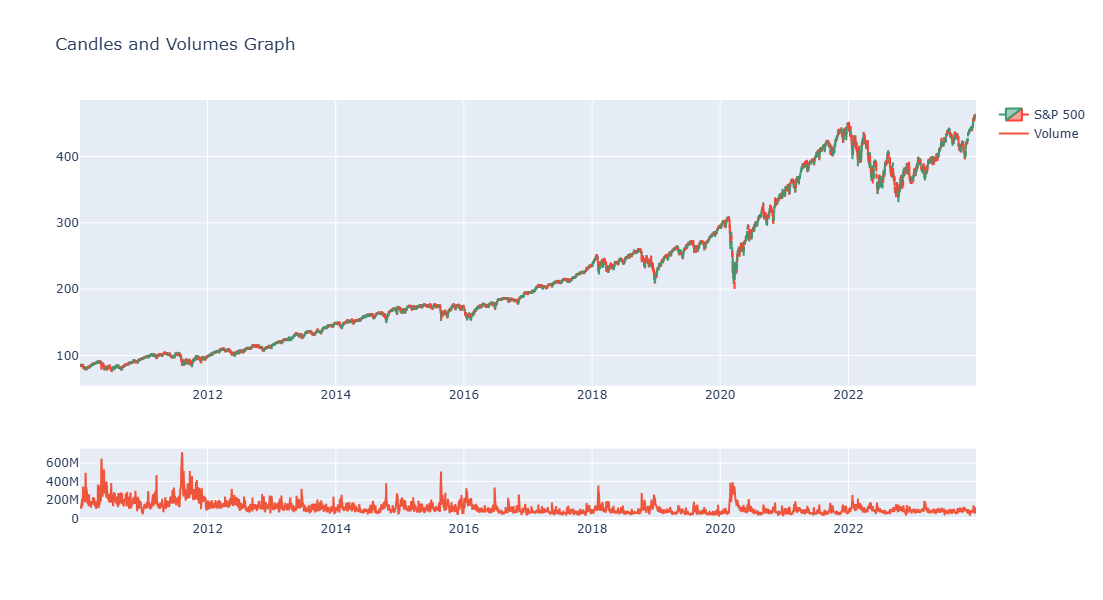

In [4]:
#Plotting data
open = df["Open"]
low = df["Low"]
close = df["Close"]
high = df["High"]
volume = df["Volume"]

fig = make_subplots(rows=2, cols=1, row_heights=[0.8, 0.2])

fig.add_trace(go.Candlestick(x=df.index, open=open.squeeze(), low=low.squeeze(), close=close.squeeze(), high=high.squeeze(), name="S&P 500"), row=1, col=1)

fig.add_trace(go.Scatter(x=df.index, y=volume.squeeze(), name="Volume"), row=2, col=1)

fig.update_layout(height=600, width=1000, title="Candles and Volumes Graph", xaxis_rangeslider_visible=False)
fig.show()

## Adding Tecnical Indicators

### Moving Averages

In [5]:
# Add different Moving Averages
windows = [9, 10, 14, 20, 21, 50]
for i in windows:
    df[f"MA_{i}"] = close.rolling(i, min_periods=i).mean()

#Data with New Variables
df

Price,Close,High,Low,Open,Volume,MA_9,MA_10,MA_14,MA_20,MA_21,MA_50
Ticker,SPY,SPY,SPY,SPY,SPY,,,,,,
Date,,,,,,,,,,,
2010-01-04,84.578491,84.623268,83.220220,83.862041,118944600,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,84.802406,84.839724,84.220291,84.526278,111579900,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,84.862083,85.071047,84.653120,84.720284,116074400,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,85.220306,85.324788,84.466539,84.705356,131091100,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-08,85.503899,85.541216,84.824766,84.996413,126402800,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,459.779938,461.459288,457.887058,459.983780,67160400,456.418033,455.441272,451.674844,448.440344,448.047118,431.322425
2023-12-26,461.721344,462.624103,460.109951,460.187625,55387000,457.865909,456.948364,453.123550,449.556920,449.072773,432.213395


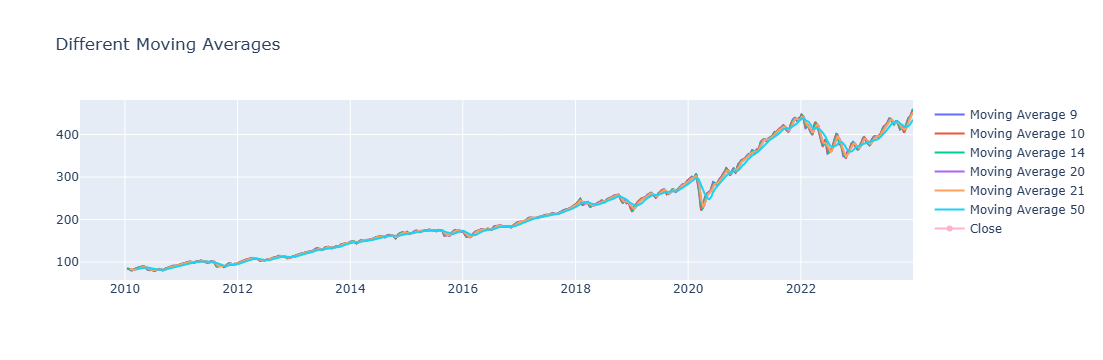

In [6]:
#Plotting
fig = go.Figure()
for i in windows:
    fig.add_trace(go.Scatter(x=df.index, y=df[f"MA_{i}"], name=f"Moving Average {i}"))

#Adding close price
fig.add_trace(go.Scatter(x=df.index, y=close, name="Close", opacity=0.5))
fig.update_layout(title="Different Moving Averages")
fig.show()

## RSI 

In [7]:
# Implement the indicator
def Relative_Strength_Index(df: pd.DataFrame, length: int = 14) -> pd.Series:
    """
    The Relative Strength Index (RSI) is a momentum indicator used in technical
    analysis that measures the magnitude of recent price changes to evaluate 
    overbought or oversold conditions in the price of a stock or other financial asset.
    """
    #Calculate
    Delta = close.diff(periods=1)
    Gain = Delta.where(Delta >= 0, 0)
    Loss = np.abs(Delta.where(Delta < 0, 0))
    avg_gain = Gain.ewm(alpha=1/length, min_periods=length).mean()
    avg_loss = Loss.ewm(alpha=1/length, min_periods=length).mean()
    RS = avg_gain / avg_loss
    RSI = pd.Series(np.where(RS == 0, 100, 100 - (100 / (1+RS))).squeeze(), name="RSI", index=df.index)

    return RSI

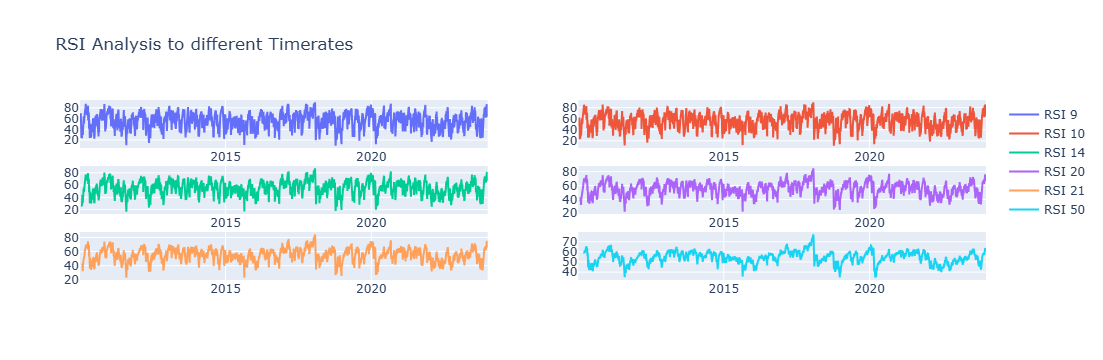

In [8]:
# Adding the indicator to our data
#windows = [9, 10, 14, 20, 21, 50]

for i in windows:
    df[f"RSI_{i}"] = Relative_Strength_Index(df, length=i)

fig = make_subplots(rows=3, cols=2)
fig.add_trace(go.Scatter(x=df.index, y=df["RSI_9"], name="RSI 9"), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["RSI_10"], name="RSI 10"), row=1, col=2)
fig.add_trace(go.Scatter(x=df.index, y=df["RSI_14"], name="RSI 14"), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["RSI_20"], name="RSI 20"), row=2, col=2)
fig.add_trace(go.Scatter(x=df.index, y=df["RSI_21"], name="RSI 21"), row=3, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["RSI_50"], name="RSI 50"), row=3, col=2)

fig.update_layout(title="RSI Analysis to different Timerates")
fig.show()

## Indicator MACD

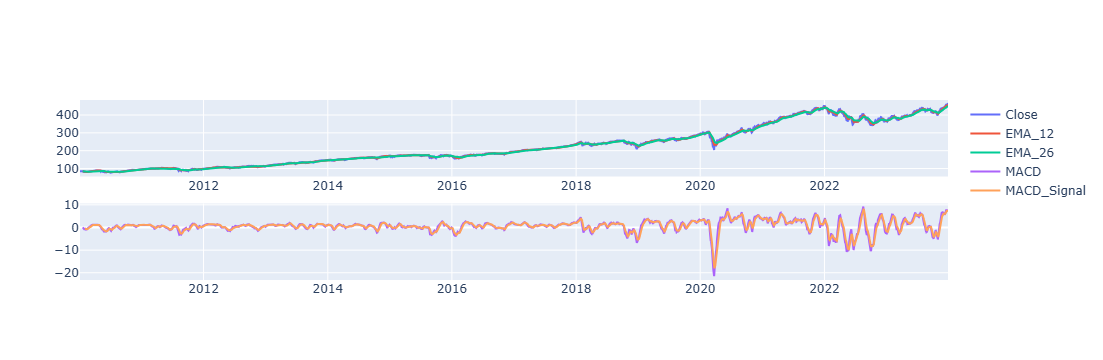

In [9]:
#Calculates Indicator

df["EMA_12"] = pd.Series(close.squeeze().ewm(span=12, min_periods=12).mean())
df["EMA_26"] = pd.Series(close.squeeze().ewm(span=26, min_periods=12).mean())
#making easier
ema12 = df["EMA_12"]
ema26 = df["EMA_26"]
#Starting again
df["MACD"] = ema12 - ema26
macd = df["MACD"]
df["MACD_signal"] = macd.ewm(span=9, min_periods=9).mean()
macd_signal = df["MACD_signal"]

#Makig the graph
fig = make_subplots(rows=2, cols=1)
fig.add_trace(go.Scatter(x=df.index, y=close.squeeze(), name="Close"), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=ema12.squeeze(), name="EMA_12"), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=ema26.squeeze(), name="EMA_26"), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=macd.squeeze(), name="MACD"), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index, y=macd_signal.squeeze(), name="MACD_Signal"), row=2, col=1)
fig.show()

# Clean and fitting the Data

In [10]:
# Displace 1 position to predict the data with a day ago (Excepting close)
Close = df["Close"]
df = df.shift(periods=1)
df["Prev_Close"] = df["Close"]
df["Close"] = Close
prevClose = df["Prev_Close"]
#Deleting the missing values
df.dropna(inplace=True)
df

Price,Close,High,Low,Open,Volume,MA_9,MA_10,MA_14,MA_20,MA_21,...,RSI_10,RSI_14,RSI_20,RSI_21,RSI_50,EMA_12,EMA_26,MACD,MACD_signal,Prev_Close
Ticker,SPY,SPY,SPY,SPY,SPY,,,,,,...,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,
2010-03-17,87.392036,86.959163,86.190473,86.429289,168673000.0,85.692134,85.503902,84.822628,84.156820,84.049317,...,83.015626,75.054485,68.287517,67.526027,59.109067,85.267086,84.161100,1.105985,0.811381,86.877075
2010-03-18,87.347252,87.675635,86.884550,87.138296,177468100.0,86.061968,85.862125,85.165394,84.412056,84.310878,...,85.206500,77.195173,70.133244,69.327855,60.327506,85.594066,84.405249,1.188817,0.886879,87.392036
2010-03-19,86.905151,87.518898,86.996489,87.399493,196509100.0,86.293323,86.190496,85.501232,84.640796,84.551827,...,84.157509,76.579695,69.761552,68.978366,60.168405,85.863833,84.627233,1.236600,0.956830,87.347252
2010-03-22,87.369736,87.894328,86.567929,86.905151,226641100.0,86.473895,86.354506,85.744186,84.838850,84.748622,...,74.145236,70.595860,66.120198,65.553047,58.611343,86.024058,84.798873,1.225186,1.010506,86.905151
2010-03-23,87.984222,87.527110,86.358079,86.410535,184477800.0,86.690331,86.563479,86.003799,85.059386,84.959368,...,77.298723,72.984786,67.969591,67.342436,59.728846,86.231111,84.992339,1.238772,1.056162,87.369736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,459.779938,459.129588,455.110806,457.527881,86667500.0,454.959198,453.955267,450.371024,447.460477,447.101020,...,70.323074,70.642811,69.091209,68.755177,61.739212,452.702932,445.039667,7.663265,7.218453,458.857788
2023-12-26,461.721344,461.459288,457.887058,459.983780,67160400.0,456.418033,455.441272,451.674844,448.440344,448.047118,...,71.371295,71.405194,69.657533,69.300344,62.015907,453.791702,446.131539,7.660164,7.306795,459.779938


## Splitting data into Training, Validation and Test

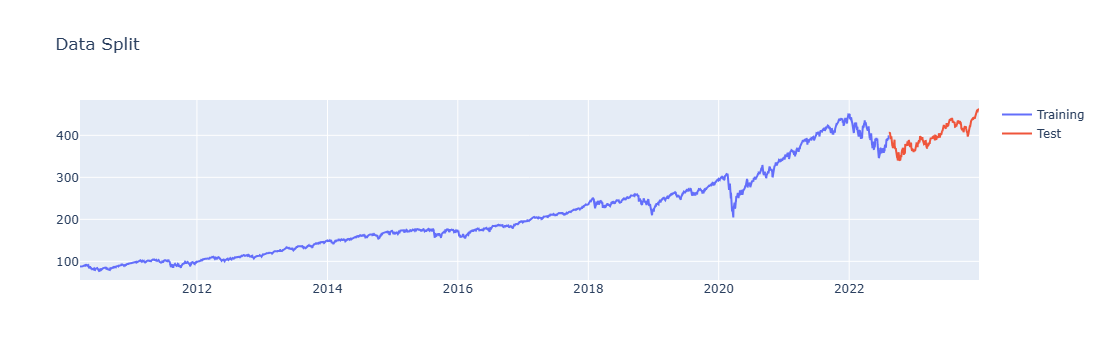

In [11]:
test_size = 0.1

#Split's index to de dataset
test_split_index = int(df.shape[0] * (1 - test_size))

#Dataset to train, validation and test
training_dataset = df.iloc[:test_split_index].copy()
test_dataset = df.iloc[test_split_index+1:].copy()

#Ploting
fig = go.Figure()
fig.add_trace(go.Scatter(x=training_dataset.index, y=training_dataset["Close"].squeeze(), name="Training"))
fig.add_trace(go.Scatter(x=test_dataset.index, y=test_dataset["Close"].squeeze(), name="Test"))
fig.update_layout(title="Data Split")
fig.show()

# Spliting Characters and Tags

In [12]:
xtrain = training_dataset.drop(columns=["Close"])
ytrain = training_dataset["Close"]

xtest = test_dataset.drop(columns=["Close"])
ytest = test_dataset["Close"]

xtrain

Price,High,Low,Open,Volume,MA_9,MA_10,MA_14,MA_20,MA_21,MA_50,...,RSI_10,RSI_14,RSI_20,RSI_21,RSI_50,EMA_12,EMA_26,MACD,MACD_signal,Prev_Close
Ticker,SPY,SPY,SPY,SPY,,,,,,,...,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,
2010-03-17,86.959163,86.190473,86.429289,168673000.0,85.692134,85.503902,84.822628,84.156820,84.049317,83.279021,...,83.015626,75.054485,68.287517,67.526027,59.109067,85.267086,84.161100,1.105985,0.811381,86.877075
2010-03-18,87.675635,86.884550,87.138296,177468100.0,86.061968,85.862125,85.165394,84.412056,84.310878,83.335292,...,85.206500,77.195173,70.133244,69.327855,60.327506,85.594066,84.405249,1.188817,0.886879,87.392036
2010-03-19,87.518898,86.996489,87.399493,196509100.0,86.293323,86.190496,85.501232,84.640796,84.551827,83.386189,...,84.157509,76.579695,69.761552,68.978366,60.168405,85.863833,84.627233,1.236600,0.956830,87.347252
2010-03-22,87.894328,86.567929,86.905151,226641100.0,86.473895,86.354506,85.744186,84.838850,84.748622,83.427050,...,74.145236,70.595860,66.120198,65.553047,58.611343,86.024058,84.798873,1.225186,1.010506,86.905151
2010-03-23,87.527110,86.358079,86.410535,184477800.0,86.690331,86.563479,86.003799,85.059386,84.959368,83.470039,...,77.298723,72.984786,67.969591,67.342436,59.728846,86.231111,84.992339,1.238772,1.056162,87.369736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-08-05,393.471832,390.959851,392.789328,45656600.0,384.750946,383.727194,380.242913,374.972220,374.675027,371.868896,...,69.743999,65.463089,60.527615,59.880225,51.722695,383.198780,376.857181,6.341599,3.908390,392.599762
2022-08-08,392.580705,388.267684,388.324557,56814900.0,386.636247,385.469464,382.377084,376.147633,375.780025,372.272220,...,68.418299,64.630895,60.025668,59.411692,51.569604,384.542987,377.974140,6.568847,4.440482,391.936127


In [13]:
#Defining the seed
torch.manual_seed(1)
np.random.seed(1)


#Resizing data (Scaling data)
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain) #Normalizing data
xtest = scaler.transform(xtest)

#Converting to tensors (For Pytorch and Tensorflow)
xtraintensor = torch.tensor(xtrain, dtype=torch.float32)
ytraintensor = torch.tensor(ytrain.values, dtype=torch.float32).reshape(-1,1)

xtesttensor = torch.tensor(xtest, dtype=torch.float32)
ytesttensor=torch.tensor(ytest.values, dtype=torch.float32).reshape(-1,1)

In [14]:
# Defining Deep neural network architecture
model = nn.Sequential(
    nn.Linear(in_features=xtraintensor.shape[1], out_features=xtraintensor.shape[1] * 4),
    nn.ReLU(),
    nn.Linear(in_features=xtraintensor.shape[1] * 4, out_features=xtraintensor.shape[1] * 4),
    nn.ReLU(),
    nn.Linear(in_features=xtraintensor.shape[1] * 4, out_features=xtraintensor.shape[1] * 4),
    nn.ReLU(),
    nn.Linear(in_features=xtraintensor.shape[1] * 4, out_features=1),
)
model
# In this case we uses this architecture for non particular propose

Sequential(
  (0): Linear(in_features=21, out_features=84, bias=True)
  (1): ReLU()
  (2): Linear(in_features=84, out_features=84, bias=True)
  (3): ReLU()
  (4): Linear(in_features=84, out_features=84, bias=True)
  (5): ReLU()
  (6): Linear(in_features=84, out_features=1, bias=True)
)

In [15]:
# Testing if our model works
model(xtraintensor)

tensor([[0.0817],
        [0.0911],
        [0.0916],
        ...,
        [0.1109],
        [0.1108],
        [0.1181]], grad_fn=<AddmmBackward0>)

In [16]:
# Defining Loss and Accuracy function
lossfunc = nn.MSELoss() #'Cause it's an Classification problem we uses Mean Squared Error
optimizer = optim.Adam(model.parameters(), lr=0.001) # We uses Adam because it's the stable model in the year that maded this code (02-09-2026, dd-mm-yyyy)
# And the viedeos creator was used that on his year saying it's the better option (2025)

#Saving the loss values
loss_values = []

#Training model
num_epochs = 3_000 # The video uses 3_000, I was runed before tree times, one with 3_000, another one with 5_000, and the lasone with 10_000, I'm going 
# to run again this with 10_000, each time the loss was decreasing
for epoch in range(num_epochs):
    #predict and get the error
    outputs = model(xtraintensor)
    loss = lossfunc(outputs, ytraintensor)

    #Backwar and optimization step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Calculates and saving the loss
    loss_values.append(loss.item())

    #Printing the loss
    if(epoch + 1) % 100 == 0:
        print(f"Epoch: [{epoch + 1} / {num_epochs}], Loss: {loss.item():.4f}")

Epoch: [100 / 3000], Loss: 5213.5098
Epoch: [200 / 3000], Loss: 2250.1443
Epoch: [300 / 3000], Loss: 662.0382
Epoch: [400 / 3000], Loss: 190.6089
Epoch: [500 / 3000], Loss: 30.9372
Epoch: [600 / 3000], Loss: 15.2837
Epoch: [700 / 3000], Loss: 11.2290
Epoch: [800 / 3000], Loss: 9.4107
Epoch: [900 / 3000], Loss: 8.3613
Epoch: [1000 / 3000], Loss: 7.7230
Epoch: [1100 / 3000], Loss: 7.2934
Epoch: [1200 / 3000], Loss: 7.0011
Epoch: [1300 / 3000], Loss: 6.7906
Epoch: [1400 / 3000], Loss: 6.6406
Epoch: [1500 / 3000], Loss: 6.5210
Epoch: [1600 / 3000], Loss: 6.4173
Epoch: [1700 / 3000], Loss: 6.3371
Epoch: [1800 / 3000], Loss: 6.2756
Epoch: [1900 / 3000], Loss: 6.2162
Epoch: [2000 / 3000], Loss: 6.1651
Epoch: [2100 / 3000], Loss: 6.1150
Epoch: [2200 / 3000], Loss: 6.0692
Epoch: [2300 / 3000], Loss: 6.0311
Epoch: [2400 / 3000], Loss: 5.9947
Epoch: [2500 / 3000], Loss: 5.9714
Epoch: [2600 / 3000], Loss: 5.9449
Epoch: [2700 / 3000], Loss: 5.9035
Epoch: [2800 / 3000], Loss: 5.9046
Epoch: [2900 / 3

In [17]:
#Making the predictions
ytrainpred = model(xtraintensor).detach().numpy().flatten()
ytestpred = model(xtesttensor).detach().numpy().flatten()

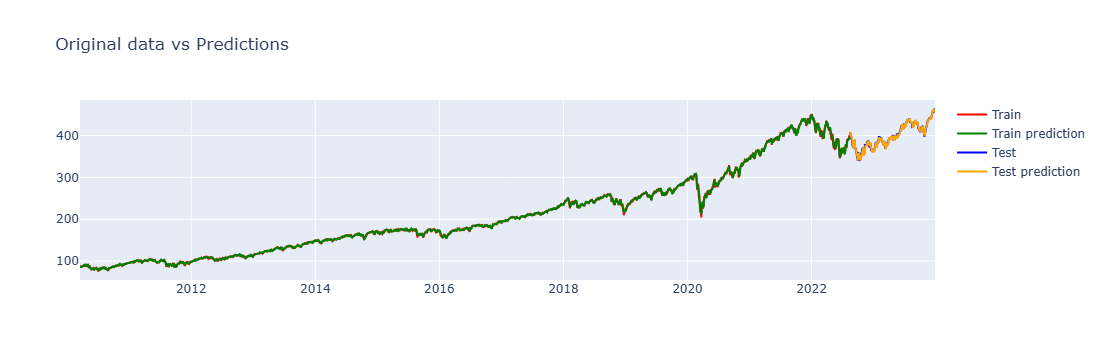

In [18]:
#Plotting
fig = go.Figure()
fig.add_trace(go.Scatter(x=training_dataset.index, y=training_dataset["Close"].squeeze(), name="Train", line=dict(color="red")))
fig.add_trace(go.Scatter(x=training_dataset.index, y=ytrainpred.squeeze(), name="Train prediction", line=dict(color="green")))
fig.add_trace(go.Scatter(x=test_dataset.index, y=test_dataset["Close"].squeeze(), name="Test", line=dict(color="blue")))
fig.add_trace(go.Scatter(x=test_dataset.index, y=ytestpred.squeeze(), name="Test prediction", line=dict(color="orange")))
fig.update_layout(title="Original data vs Predictions")
fig.show()

In [19]:
# Calculates absolute error into the train and test datasets
mae_training = mean_absolute_error(ytrain, ytrainpred)
mae_test = mean_absolute_error(ytest,ytestpred)

print(f"MAE into the training dataset = {mae_training}")
print(f"MAE into the test dataset = {mae_test}")

MAE into the training dataset = 1.5356335639953613
MAE into the test dataset = 3.3539164066314697


# Reminder

- Deep Neural Networks possess an extraordinary capacity to decipher intricate patterns in financial data, facilitating more accurate asset price forecasting.